# WNT5A spatial gene-expression analysis with hierarchical Gaussian processes

This notebook reproduces the WNT5A analysis in two stages:

1. **Spatial-gene screen.** For every gene, compare a fixed-noise constant-kernel
   Gaussian process with a fixed-noise RBF Gaussian process. The RBF model is
   optimized from three length-scale starts (10, 50, and 200 µm). An approximate
   boundary likelihood-ratio p-value is adjusted across all genes with
   Benjamini-Hochberg (BH) FDR control at 0.05.
2. **Hierarchical GP clustering.** Subset to the BH-significant genes, subtract
   each gene's stabilized inverse-variance weighted mean, and fit a four-component
   hierarchical mixture of Gaussian processes (GPClust/MOHGP) from ten independent
   random starts.

The accepted WNT5A run selects **323 of 10,789 genes** and has best GPClust
restart seed 5. Cluster labels are arbitrary and can permute across platforms.

Expected runtime in the pinned environment is about 20–25 minutes for the
all-gene screen and less than one minute for the ten clustering restarts.



## Setup

Use a dedicated Python 3.12 environment. The analysis was validated with:

- NumPy 1.26.4
- SciPy 1.12.0
- pandas 2.2.3
- Matplotlib 3.10.0
- GPy 1.13.2
- GPClust commit `9f746598f2e383db5a4e89ef3bfc0270451c7873`

Installing these pins into a newer `anndata` environment can create dependency
conflicts, so an isolated environment is strongly recommended. To install the
analysis dependencies in the active isolated environment, set
`INSTALL_DEPENDENCIES = True` below and run the cell once. Launch Jupyter from
that environment or select its standard `python3` kernel before running.



In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "numpy==1.26.4",
            "scipy==1.12.0",
            "pandas==2.2.3",
            "matplotlib==3.10.0",
            "GPy==1.13.2",
            "gdown",
            "h5py",
            "ipykernel",
            "scikit-learn==1.6.1",
            "git+https://github.com/SheffieldML/GPclust.git"
            "@9f746598f2e383db5a4e89ef3bfc0270451c7873",
        ],
        check=True,
    )
else:
    print("Dependency installation skipped; using the active Python environment.")



In [2]:
from __future__ import annotations

import gc
import hashlib
import importlib
import json
import os
import sys
import time
import warnings
from importlib import metadata as importlib_metadata
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import linalg
from scipy.sparse import csr_matrix
from scipy.spatial import KDTree
from scipy.stats import chi2

try:
    import GPy
except ImportError as exc:
    raise ImportError(
        "GPy is required. Create the isolated environment described above, "
        "then restart the kernel."
    ) from exc

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)
mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

DATA_DIR = Path("data")
OUTPUT_DIR = Path(os.environ.get("WNT5A_OUTPUT_DIR", "output/wnt5a_gpclust"))
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

input_override = os.environ.get("WNT5A_NPZ")
if input_override:
    INPUT_NPZ = Path(input_override)
    if not INPUT_NPZ.is_file():
        raise FileNotFoundError(
            f"WNT5A_NPZ was explicitly set but does not exist: {INPUT_NPZ}"
        )
else:
    input_candidates = [
        DATA_DIR / "WNT5A_inputs.npz",
        DATA_DIR / "WNT5A.npz",
        DATA_DIR / "inputs.npz",
        Path("inputs.npz"),
    ]
    INPUT_NPZ = next(
        (path for path in input_candidates if path.is_file()),
        DATA_DIR / "WNT5A_inputs.npz",
    )
CATATAC_PATH = DATA_DIR / "all_lanes_CATATAC.h5mu"
CATATAC_DRIVE_ID = "1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo"

SCREEN_RESULTS_PATH = Path(
    os.environ.get(
        "WNT5A_SCREEN_RESULTS",
        OUTPUT_DIR / "spatial_lrt_results.tsv",
    )
)
CLUSTER_RESULTS_PATH = Path(
    os.environ.get(
        "WNT5A_CLUSTER_RESULTS",
        OUTPUT_DIR / "gpclust_results.npz",
    )
)
RESTART_SUMMARY_PATH = Path(
    os.environ.get(
        "WNT5A_RESTART_SUMMARY",
        OUTPUT_DIR / "restart_summary.tsv",
    )
)

FORCE_SCREEN = os.environ.get("WNT5A_FORCE_SCREEN", "0") == "1"
FORCE_CLUSTER = os.environ.get("WNT5A_FORCE_CLUSTER", "0") == "1"

print(f"Input: {INPUT_NPZ}")
print(f"Output: {OUTPUT_DIR}")
print(f"GPy: {GPy.__version__}; NumPy: {np.__version__}")



## 1. Prepare or load the WNT5A binned input

If `WNT5A_NPZ` points to an existing compact input archive, the notebook uses
it directly. Otherwise it downloads the multiome data from Google Drive,
computes within-embryoid-body distance to the nearest WNT5A knockdown cell,
and creates 30 pseudobulk bins with midpoints 5, 15, ..., 295 µm.



In [3]:
def read_sparse(group):
    data = group["data"][:]
    indices = group["indices"][:]
    indptr = group["indptr"][:]
    shape = tuple(group.attrs["shape"])
    encoding = group.attrs.get("encoding-type", b"csr_matrix")
    if isinstance(encoding, bytes):
        encoding = encoding.decode()
    if "csc" in encoding:
        from scipy.sparse import csc_matrix

        return csc_matrix((data, indices, indptr), shape=shape)
    return csr_matrix((data, indices, indptr), shape=shape)


def read_categorical(group):
    if isinstance(group, h5py.Dataset):
        return np.array(
            [
                value.decode() if isinstance(value, bytes) else value
                for value in group[:]
            ]
        )
    categories = np.array(
        [
            value.decode() if isinstance(value, bytes) else value
            for value in group["categories"][:]
        ]
    )
    return categories[group["codes"][:]]


def load_raw_multiome():
    if not CATATAC_PATH.is_file():
        import gdown

        gdown.download(
            id=CATATAC_DRIVE_ID,
            output=str(CATATAC_PATH),
            quiet=False,
        )
    with h5py.File(CATATAC_PATH, "r") as handle:
        raw = {
            "target_calls": read_categorical(handle["obs"]["target_call"]),
            "eb_clusters": read_categorical(
                handle["obs"]["EB_manual_clustering"]
            ),
            "spatial": np.column_stack(
                [
                    np.asarray(handle["obs"]["SPATIAL_1"][:], dtype=float),
                    np.asarray(handle["obs"]["SPATIAL_2"][:], dtype=float),
                ]
            ),
            "rna_X": read_sparse(
                handle["mod"]["rna"]["layers"]["log1p_normalized"]
            ),
            "gene_names": np.array(
                [
                    value.decode() if isinstance(value, bytes) else value
                    for value in handle["mod"]["rna"]["var"]["_index"][:]
                ]
            ),
        }
    return raw


def compute_wnt5a_binned_input():
    raw = load_raw_multiome()
    target_calls = raw["target_calls"]
    eb_clusters = raw["eb_clusters"]
    spatial = raw["spatial"]
    rna_X = raw["rna_X"]
    all_gene_names = raw["gene_names"]

    target = "WNT5A"
    excluded = {"Unassigned", "No_CRISPR_data", "Non-Targeting"}
    kd_mask = target_calls == target
    non_kd_mask = np.array(
        [
            value not in excluded and value != target
            for value in target_calls
        ]
    )
    distances = np.full(target_calls.size, np.inf)
    for eb in np.unique(eb_clusters):
        in_eb = eb_clusters == eb
        reference = kd_mask & in_eb
        query = non_kd_mask & in_eb
        if reference.sum() < 1 or query.sum() < 1:
            continue
        distance, _ = KDTree(spatial[reference]).query(spatial[query])
        distances[np.flatnonzero(query)] = distance

    valid = non_kd_mask & (distances <= 300)
    bins = [(10 * i, 10 * (i + 1)) for i in range(30)]
    bin_cells = []
    for index, (lower, upper) in enumerate(bins):
        upper_test = distances <= upper if index == 29 else distances < upper
        bin_cells.append(
            np.flatnonzero(
                valid & (distances >= lower) & upper_test
            )
        )
    bin_counts = np.array([cells.size for cells in bin_cells], dtype=int)
    if np.any(bin_counts == 0):
        raise ValueError(f"At least one WNT5A distance bin is empty: {bin_counts}")

    all_cells = np.concatenate(bin_cells)
    detection = np.asarray((rna_X[all_cells] != 0).mean(axis=0)).ravel()
    gene_indices = np.flatnonzero(detection > 0.05)
    means = np.empty((30, gene_indices.size), dtype=float)
    sems = np.empty_like(means)
    for index, cells in enumerate(bin_cells):
        values = rna_X[cells][:, gene_indices].toarray()
        means[index] = values.mean(axis=0)
        sems[index] = values.std(axis=0, ddof=0) / np.sqrt(cells.size)

    payload = {
        "X": (5.0 + 10.0 * np.arange(30))[:, None],
        "means": means,
        "sems": sems,
        "mean_sem_sq": np.mean(np.square(sems), axis=0),
        "detection": detection[gene_indices],
        "gene_names": all_gene_names[gene_indices],
        "gene_indices": gene_indices,
        "bin_counts": bin_counts,
    }
    INPUT_NPZ.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(INPUT_NPZ, **payload)
    print(
        f"Created {INPUT_NPZ}: {gene_indices.size:,} genes, "
        f"{all_cells.size:,} binned cells"
    )


if INPUT_NPZ.is_file():
    print(f"Using existing compact input: {INPUT_NPZ}")
else:
    compute_wnt5a_binned_input()



In [4]:
def orient_gene_by_bin(values, n_bins, n_genes, name):
    array = np.asarray(values, dtype=float)
    if array.shape == (n_genes, n_bins):
        return np.ascontiguousarray(array)
    if array.shape == (n_bins, n_genes):
        return np.ascontiguousarray(array.T)
    raise ValueError(
        f"{name} has shape {array.shape}; expected "
        f"({n_genes}, {n_bins}) or ({n_bins}, {n_genes})."
    )


with np.load(INPUT_NPZ, allow_pickle=False) as archive:
    required = {
        "X",
        "means",
        "sems",
        "mean_sem_sq",
        "detection",
        "gene_names",
        "gene_indices",
        "bin_counts",
    }
    missing = sorted(required.difference(archive.files))
    if missing:
        raise ValueError(f"Input archive is missing: {', '.join(missing)}")
    X = np.asarray(archive["X"], dtype=float)
    gene_names = np.asarray(archive["gene_names"]).astype(str)
    gene_indices = np.asarray(archive["gene_indices"], dtype=int)
    detection = np.asarray(archive["detection"], dtype=float)
    mean_sem_sq = np.asarray(archive["mean_sem_sq"], dtype=float)
    bin_counts = np.asarray(archive["bin_counts"], dtype=int)
    Y_mean = orient_gene_by_bin(
        archive["means"], X.shape[0], gene_names.size, "means"
    )
    Y_sem = orient_gene_by_bin(
        archive["sems"], X.shape[0], gene_names.size, "sems"
    )

assert X.shape == (30, 1)
assert np.all(np.diff(X[:, 0]) > 0)
assert Y_mean.shape == Y_sem.shape == (gene_names.size, 30)
assert gene_names.size == mean_sem_sq.size == 10_789
assert np.all(np.isfinite(Y_mean))
assert np.all(np.isfinite(Y_sem))
assert np.all(mean_sem_sq > 0)
assert np.allclose(
    mean_sem_sq,
    np.mean(np.square(Y_sem), axis=1),
    rtol=1e-10,
    atol=1e-14,
)


def semantic_array_hash(named_arrays):
    digest = hashlib.sha256()
    for name, values in named_arrays:
        array = np.ascontiguousarray(values)
        digest.update(name.encode("utf-8"))
        digest.update(str(array.shape).encode("ascii"))
        digest.update(array.dtype.str.encode("ascii"))
        digest.update(array.tobytes(order="C"))
    return digest.hexdigest()


input_semantic_sha256 = semantic_array_hash(
    [
        ("X", X),
        ("Y_mean", Y_mean),
        ("Y_sem", Y_sem),
        ("gene_names", gene_names),
        ("gene_indices", gene_indices),
        ("detection", detection),
        ("bin_counts", bin_counts),
    ]
)

display(
    pd.DataFrame(
        {
            "quantity": [
                "distance bins",
                "tested genes",
                "binned cells",
                "first / last midpoint",
            ],
            "value": [
                X.shape[0],
                gene_names.size,
                int(bin_counts.sum()),
                f"{X[0, 0]:g} / {X[-1, 0]:g} µm",
            ],
        }
    )
)



## 2. Fixed-noise spatial likelihood-ratio screen

For each gene, both models use the same fixed scalar noise variance,
`mean(SEM² across bins)`. The null covariance is constant
(`GPy.kern.Bias`); the alternative is RBF and is optimized from deterministic
length-scale starts of 10, 50, and 200 µm.

The statistic is `max(0, 2 × (log L_RBF − log L_constant))`. Because the
constant model is approached at the infinite-length-scale boundary of the
RBF model, the primary p-value uses the approximate 50:50
χ²₀/χ²₁ boundary mixture. BH adjustment is applied over all 10,789 genes.



In [5]:
RBF_STARTS_UM = (10.0, 50.0, 200.0)
MAX_OPTIMIZER_ITERS = 1000
FDR_THRESHOLD = 0.05

screen_configuration = {
    "input_semantic_sha256": input_semantic_sha256,
    "null_kernel": "GPy.kern.Bias",
    "alternative_kernel": "GPy.kern.RBF",
    "rbf_initial_lengthscales_um": RBF_STARTS_UM,
    "max_optimizer_iters": MAX_OPTIMIZER_ITERS,
    "fixed_noise": "mean(SEM^2 across bins) per gene",
    "lrt_reference": "0.5*chi-square(0)+0.5*chi-square(1)",
    "fdr_method": "Benjamini-Hochberg",
    "fdr_threshold": FDR_THRESHOLD,
    "GPy_version": GPy.__version__,
}
screen_cache_key = hashlib.sha256(
    json.dumps(
        screen_configuration,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


def scalar(value):
    return float(np.asarray(value, dtype=float).reshape(-1)[0])


def fit_fixed_noise_gp(
    x,
    y,
    noise_variance,
    kernel_kind,
    initial_lengthscale=None,
):
    signal_variance = max(
        float(np.mean(np.square(y))),
        float(noise_variance),
        1e-12,
    )
    if kernel_kind == "constant":
        kernel = GPy.kern.Bias(1, variance=signal_variance)
    elif kernel_kind == "rbf":
        kernel = GPy.kern.RBF(
            1,
            variance=signal_variance,
            lengthscale=float(initial_lengthscale),
        )
    else:
        raise ValueError(kernel_kind)

    model = GPy.models.GPRegression(
        np.ascontiguousarray(x, dtype=float),
        np.ascontiguousarray(y, dtype=float)[:, None],
        kernel=kernel,
        noise_var=float(noise_variance),
        normalizer=False,
    )
    model.Gaussian_noise.variance.fix(float(noise_variance))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        optimizer = model.optimize(
            optimizer="lbfgsb",
            messages=False,
            max_iters=MAX_OPTIMIZER_ITERS,
        )
    if scalar(model.Gaussian_noise.variance) != float(noise_variance):
        raise RuntimeError("The fixed GP noise variance changed.")
    return {
        "log_likelihood": float(model.log_likelihood()),
        "kernel_variance": scalar(model.kern.variance),
        "lengthscale_um": (
            scalar(model.kern.lengthscale)
            if kernel_kind == "rbf"
            else np.nan
        ),
        "optimizer_status": str(getattr(optimizer, "status", "unknown")),
    }


def screen_one_gene(position):
    y = Y_mean[position]
    noise = float(mean_sem_sq[position])
    constant = fit_fixed_noise_gp(X, y, noise, "constant")
    alternatives = []
    errors = []
    for start in RBF_STARTS_UM:
        try:
            fit = fit_fixed_noise_gp(X, y, noise, "rbf", start)
            fit["initial_lengthscale_um"] = start
            alternatives.append(fit)
        except Exception as exc:
            errors.append(f"{start:g}: {type(exc).__name__}: {exc}")
    if not alternatives:
        raise RuntimeError("All RBF starts failed: " + " | ".join(errors))

    rbf = max(alternatives, key=lambda item: item["log_likelihood"])
    raw_lr = 2.0 * (
        rbf["log_likelihood"] - constant["log_likelihood"]
    )
    lr = max(0.0, raw_lr)
    chi_square_p = float(chi2.sf(lr, df=1)) if lr > 0 else 1.0
    boundary_p = 0.5 * chi_square_p if lr > 0 else 1.0
    return {
        "input_gene_position": position,
        "gene": gene_names[position],
        "gene_index": int(gene_indices[position]),
        "fit_success": True,
        "fixed_noise_variance": noise,
        "constant_log_likelihood": constant["log_likelihood"],
        "constant_kernel_variance": constant["kernel_variance"],
        "constant_optimizer_status": constant["optimizer_status"],
        "rbf_log_likelihood": rbf["log_likelihood"],
        "rbf_kernel_variance": rbf["kernel_variance"],
        "rbf_lengthscale_um": rbf["lengthscale_um"],
        "rbf_selected_initial_lengthscale_um": rbf[
            "initial_lengthscale_um"
        ],
        "rbf_optimizer_status": rbf["optimizer_status"],
        "rbf_successful_start_count": len(alternatives),
        "rbf_failed_start_count": len(errors),
        "raw_likelihood_ratio": raw_lr,
        "likelihood_ratio_statistic": lr,
        "p_value": boundary_p,
        "p_value_chi_square_1_sensitivity": chi_square_p,
        "error": "",
    }


def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values, kind="stable")
    ranked = values[order]
    ranks = np.arange(1, values.size + 1, dtype=float)
    adjusted_ranked = np.minimum.accumulate(
        (ranked * values.size / ranks)[::-1]
    )[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0.0, 1.0)
    return adjusted


def normalize_boolean_column(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    return series.astype(str).str.lower().eq("true")



In [6]:
required_screen_columns = {
    "input_gene_position",
    "gene",
    "fit_success",
    "fixed_noise_variance",
    "constant_log_likelihood",
    "constant_kernel_variance",
    "rbf_log_likelihood",
    "rbf_kernel_variance",
    "rbf_lengthscale_um",
    "raw_likelihood_ratio",
    "likelihood_ratio_statistic",
    "p_value",
    "fdr_q_value",
    "significant_fdr",
}

if SCREEN_RESULTS_PATH.is_file() and not FORCE_SCREEN:
    screen_results = pd.read_csv(SCREEN_RESULTS_PATH, sep="\t")
    print(f"Loaded cached screen: {SCREEN_RESULTS_PATH}")
else:
    rows = []
    started = time.perf_counter()
    for position in range(gene_names.size):
        try:
            row = screen_one_gene(position)
        except Exception as exc:
            row = {
                "input_gene_position": position,
                "gene": gene_names[position],
                "gene_index": int(gene_indices[position]),
                "fit_success": False,
                "fixed_noise_variance": float(mean_sem_sq[position]),
                "p_value": 1.0,
                "p_value_chi_square_1_sensitivity": 1.0,
                "error": f"{type(exc).__name__}: {exc}",
            }
        rows.append(row)
        if (position + 1) % 500 == 0 or position + 1 == gene_names.size:
            print(
                f"Screened {position + 1:,}/{gene_names.size:,} genes "
                f"in {time.perf_counter() - started:.0f}s"
            )
    screen_results = pd.DataFrame(rows).sort_values(
        "input_gene_position", kind="stable"
    )
    screen_results["fdr_q_value"] = benjamini_hochberg(
        screen_results["p_value"].to_numpy(float)
    )
    screen_results["chi_square_1_bh_q_value_sensitivity"] = (
        benjamini_hochberg(
            screen_results[
                "p_value_chi_square_1_sensitivity"
            ].to_numpy(float)
        )
    )
    harmonic_factor = np.sum(
        1.0 / np.arange(1, gene_names.size + 1, dtype=float)
    )
    screen_results["by_q_value_sensitivity"] = np.minimum(
        1.0,
        screen_results["fdr_q_value"] * harmonic_factor,
    )
    screen_results["significant_fdr"] = (
        screen_results["fit_success"]
        & (screen_results["fdr_q_value"] <= FDR_THRESHOLD)
    )
    screen_results["mean_expression"] = Y_mean.mean(axis=1)
    screen_results["expression_range"] = np.ptp(Y_mean, axis=1)
    screen_results["screen_cache_key"] = screen_cache_key
    SCREEN_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    screen_results.to_csv(SCREEN_RESULTS_PATH, sep="\t", index=False)

missing = sorted(required_screen_columns.difference(screen_results.columns))
if missing:
    raise ValueError(f"Screen cache is missing columns: {', '.join(missing)}")
screen_results = screen_results.sort_values(
    "input_gene_position", kind="stable"
).reset_index(drop=True)
screen_results["fit_success"] = normalize_boolean_column(
    screen_results["fit_success"]
)
screen_results["significant_fdr"] = normalize_boolean_column(
    screen_results["significant_fdr"]
)
assert screen_results.shape[0] == gene_names.size
assert np.array_equal(
    screen_results["input_gene_position"].to_numpy(int),
    np.arange(gene_names.size),
)
assert np.array_equal(
    screen_results["gene"].astype(str).to_numpy(),
    gene_names,
)
successful_screen = screen_results["fit_success"].to_numpy(bool)
for column in (
    "constant_log_likelihood",
    "constant_kernel_variance",
    "rbf_log_likelihood",
    "rbf_kernel_variance",
    "rbf_lengthscale_um",
    "likelihood_ratio_statistic",
    "p_value",
):
    assert np.all(
        np.isfinite(
            screen_results.loc[successful_screen, column].to_numpy(float)
        )
    ), f"Non-finite successful-fit values in {column}."
for column in (
    "constant_kernel_variance",
    "rbf_kernel_variance",
    "rbf_lengthscale_um",
):
    assert np.all(
        screen_results.loc[successful_screen, column].to_numpy(float) > 0.0
    ), f"Non-positive successful-fit values in {column}."

calculated_raw_lr = 2.0 * (
    screen_results.loc[
        successful_screen, "rbf_log_likelihood"
    ].to_numpy(float)
    - screen_results.loc[
        successful_screen, "constant_log_likelihood"
    ].to_numpy(float)
)
assert np.allclose(
    screen_results.loc[
        successful_screen, "raw_likelihood_ratio"
    ].to_numpy(float),
    calculated_raw_lr,
    rtol=1e-8,
    atol=1e-8,
)
assert np.allclose(
    screen_results.loc[
        successful_screen, "likelihood_ratio_statistic"
    ].to_numpy(float),
    np.maximum(0.0, calculated_raw_lr),
    rtol=1e-8,
    atol=1e-8,
)
if "screen_cache_key" in screen_results:
    cached_keys = screen_results["screen_cache_key"].astype(str).unique()
    if cached_keys.tolist() != [screen_cache_key]:
        raise ValueError(
            "The cached spatial screen was generated from a different "
            "input matrix or model configuration."
        )
elif os.environ.get("WNT5A_SCREEN_RESULTS"):
    warnings.warn(
        "The explicitly supplied legacy screen cache predates exact content "
        "signatures; validating gene identities, noise, expression means, "
        "ranges, p-values, and q-values instead.",
        stacklevel=2,
    )
else:
    raise ValueError(
        "The cached screen predates exact provenance signatures. Delete it "
        "or set WNT5A_FORCE_SCREEN=1 to regenerate it."
    )
assert np.allclose(
    screen_results["fixed_noise_variance"].to_numpy(float),
    mean_sem_sq,
    rtol=1e-10,
    atol=1e-14,
)
if "mean_expression" in screen_results:
    assert np.allclose(
        screen_results["mean_expression"].to_numpy(float),
        Y_mean.mean(axis=1),
        rtol=1e-10,
        atol=1e-12,
    )
if "expression_range" in screen_results:
    assert np.allclose(
        screen_results["expression_range"].to_numpy(float),
        np.ptp(Y_mean, axis=1),
        rtol=1e-10,
        atol=1e-12,
    )

recomputed_q_values = benjamini_hochberg(
    screen_results["p_value"].to_numpy(float)
)
assert np.allclose(
    screen_results["fdr_q_value"].to_numpy(float),
    recomputed_q_values,
    rtol=1e-8,
    atol=1e-12,
)
screen_results["fdr_q_value"] = recomputed_q_values
expected_boundary_p = np.where(
    screen_results["likelihood_ratio_statistic"].to_numpy(float) > 0.0,
    0.5
    * chi2.sf(
        screen_results["likelihood_ratio_statistic"].to_numpy(float),
        df=1,
    ),
    1.0,
)
assert np.allclose(
    screen_results["p_value"].to_numpy(float),
    expected_boundary_p,
    rtol=1e-8,
    atol=1e-12,
)

if "by_q_value_sensitivity" not in screen_results:
    harmonic_factor = np.sum(
        1.0 / np.arange(1, gene_names.size + 1, dtype=float)
    )
    screen_results["by_q_value_sensitivity"] = np.minimum(
        1.0,
        screen_results["fdr_q_value"] * harmonic_factor,
    )

significant_mask = (
    screen_results["fit_success"]
    & (screen_results["fdr_q_value"] <= FDR_THRESHOLD)
)
screen_results["significant_fdr"] = significant_mask
selected_positions = screen_results.loc[
    significant_mask, "input_gene_position"
].to_numpy(int)

screen_summary = pd.DataFrame(
    {
        "criterion": [
            "Genes tested",
            "Fit failures",
            "BH FDR ≤ 0.05",
            "BY sensitivity ≤ 0.05",
        ],
        "genes": [
            screen_results.shape[0],
            int((~screen_results["fit_success"]).sum()),
            int(significant_mask.sum()),
            int((screen_results["by_q_value_sensitivity"] <= 0.05).sum()),
        ],
    }
)
display(screen_summary)
if selected_positions.size != 323:
    warnings.warn(
        f"The pinned WNT5A reference selected 323 genes; this run selected "
        f"{selected_positions.size}. Clustering will use the observed set.",
        stacklevel=2,
    )



Validated screen: 10,789 genes; 323 BH-significant; 97 BY-significant.


## 3. Top ten spatial GP fits

The shaded band is the **posterior predictive** interval, including the fixed
observation-noise likelihood. Bin-specific SEMs are shown separately as error
bars. Ranking is by boundary-mixture p-value, then decreasing LR statistic,
then gene name. The reported coverage is an in-sample diagnostic at the 30
training-bin means, not out-of-sample predictive calibration.



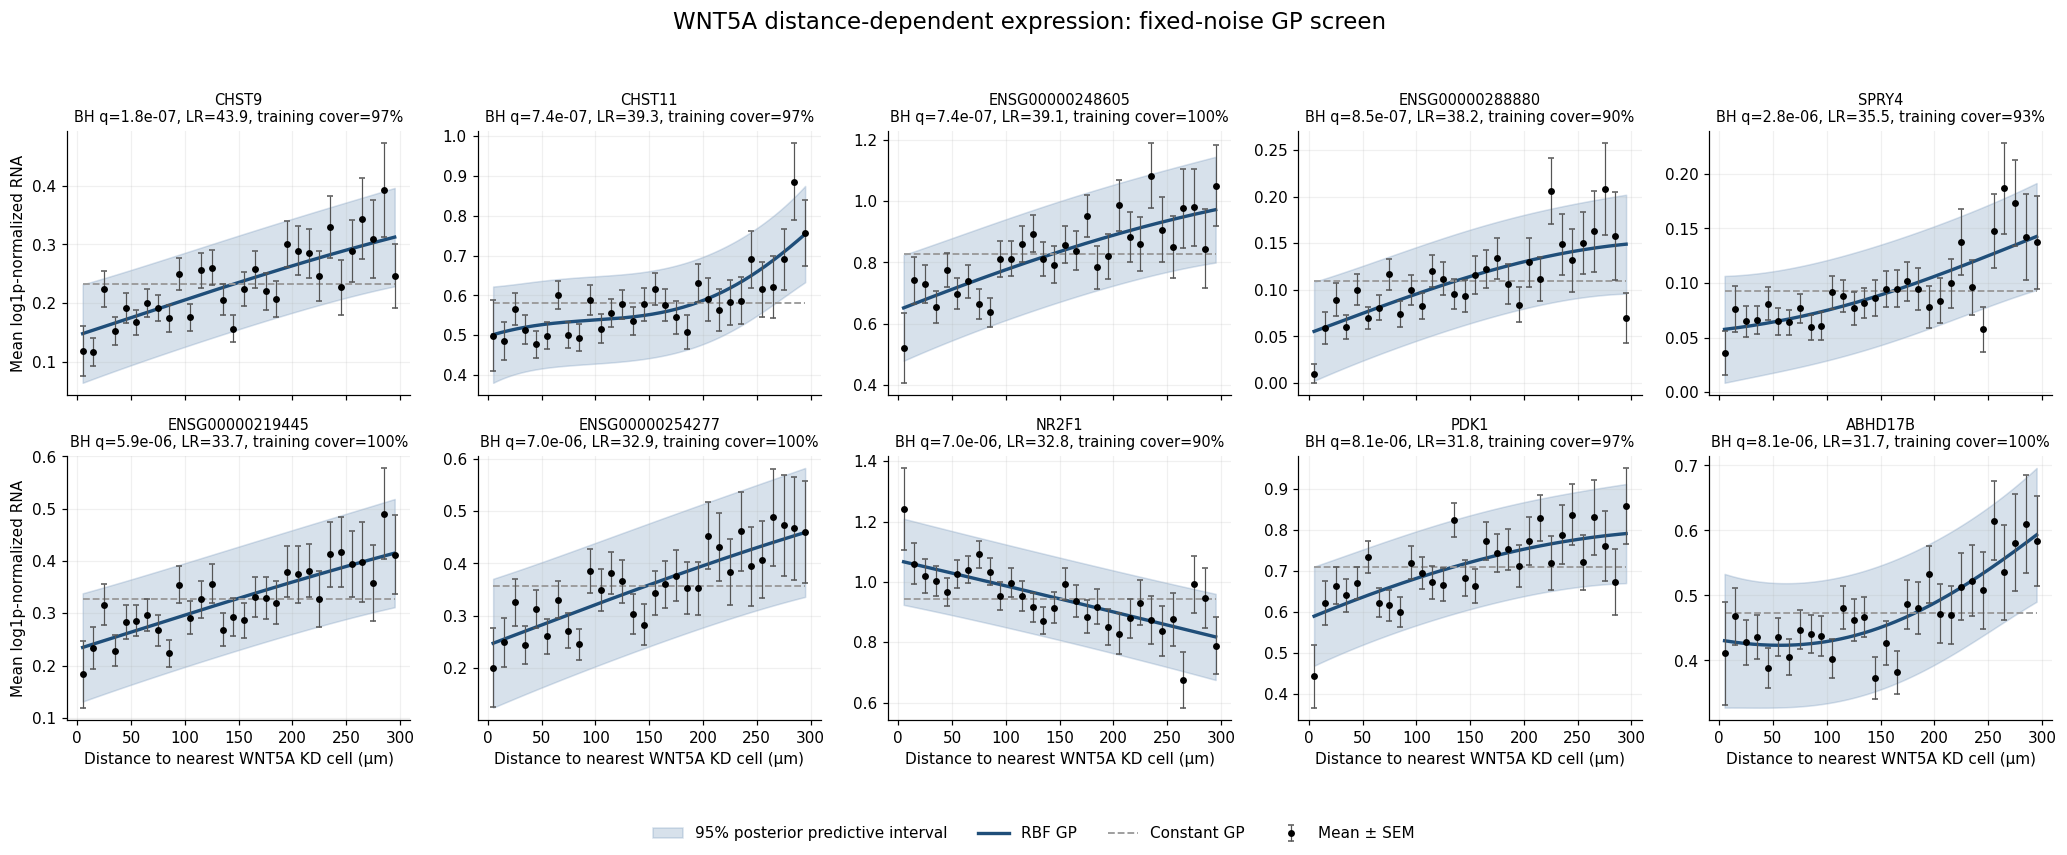

In [7]:
def reconstruct_gp(
    position,
    kernel_kind,
    kernel_variance,
    noise_variance,
    lengthscale=None,
):
    if kernel_kind == "constant":
        kernel = GPy.kern.Bias(1, variance=float(kernel_variance))
    else:
        kernel = GPy.kern.RBF(
            1,
            variance=float(kernel_variance),
            lengthscale=float(lengthscale),
        )
    model = GPy.models.GPRegression(
        X,
        Y_mean[position, :, None],
        kernel=kernel,
        noise_var=float(noise_variance),
        normalizer=False,
    )
    model.Gaussian_noise.variance.fix(float(noise_variance))
    return model


top10 = (
    screen_results.loc[significant_mask]
    .sort_values(
        ["p_value", "likelihood_ratio_statistic", "gene"],
        ascending=[True, False, True],
        kind="stable",
    )
    .head(10)
    .reset_index(drop=True)
)
prediction_X = np.linspace(X[0, 0], X[-1, 0], 291)[:, None]
figure, axes = plt.subplots(2, 5, figsize=(19, 7.8), sharex=True)
plot_rows = []

for axis, (_, row) in zip(axes.ravel(), top10.iterrows()):
    position = int(row["input_gene_position"])
    noise = float(row["fixed_noise_variance"])
    constant_model = reconstruct_gp(
        position,
        "constant",
        row["constant_kernel_variance"],
        noise,
    )
    rbf_model = reconstruct_gp(
        position,
        "rbf",
        row["rbf_kernel_variance"],
        noise,
        row["rbf_lengthscale_um"],
    )
    constant_mean, _ = constant_model.predict(
        prediction_X,
        include_likelihood=False,
    )
    rbf_mean, rbf_variance = rbf_model.predict(
        prediction_X,
        include_likelihood=True,
    )
    rbf_sd = np.sqrt(np.maximum(rbf_variance[:, 0], 0.0))
    lower = rbf_mean[:, 0] - 1.96 * rbf_sd
    upper = rbf_mean[:, 0] + 1.96 * rbf_sd

    fitted_at_bins, variance_at_bins = rbf_model.predict(
        X,
        include_likelihood=True,
    )
    sd_at_bins = np.sqrt(np.maximum(variance_at_bins[:, 0], 0.0))
    covered = np.mean(
        (Y_mean[position] >= fitted_at_bins[:, 0] - 1.96 * sd_at_bins)
        & (Y_mean[position] <= fitted_at_bins[:, 0] + 1.96 * sd_at_bins)
    )
    plot_rows.append(
        {
            "gene": row["gene"],
            "LR": row["likelihood_ratio_statistic"],
            "BH q-value": row["fdr_q_value"],
            "RBF length scale (µm)": row["rbf_lengthscale_um"],
            "training-bin predictive coverage": covered,
        }
    )

    axis.fill_between(
        prediction_X[:, 0],
        lower,
        upper,
        color="#4C78A8",
        alpha=0.22,
        label="95% posterior predictive interval",
    )
    axis.plot(
        prediction_X[:, 0],
        rbf_mean[:, 0],
        color="#1F4E79",
        linewidth=2.2,
        label="RBF GP",
    )
    axis.plot(
        prediction_X[:, 0],
        constant_mean[:, 0],
        color="#999999",
        linestyle="--",
        linewidth=1.2,
        label="Constant GP",
    )
    axis.errorbar(
        X[:, 0],
        Y_mean[position],
        yerr=Y_sem[position],
        fmt="o",
        markersize=3.5,
        color="black",
        ecolor="#555555",
        elinewidth=0.8,
        capsize=2,
        label="Mean ± SEM",
    )
    axis.set_title(
        f"{row['gene']}\n"
        f"BH q={row['fdr_q_value']:.1e}, "
        f"LR={row['likelihood_ratio_statistic']:.1f}, "
        f"training cover={covered:.0%}",
        fontsize=9.5,
    )
    axis.grid(alpha=0.18)

for axis in axes[-1]:
    axis.set_xlabel("Distance to nearest WNT5A KD cell (µm)")
for axis in axes[:, 0]:
    axis.set_ylabel("Mean log1p-normalized RNA")

handles, labels = axes[0, 0].get_legend_handles_labels()
figure.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
)
figure.suptitle(
    "WNT5A distance-dependent expression: fixed-noise GP screen",
    fontsize=15,
)
figure.tight_layout(rect=[0, 0.08, 1, 0.95])
figure.savefig(
    OUTPUT_DIR / "top10_wnt5a_spatial_gp_fits.png",
    bbox_inches="tight",
)
figure.savefig(
    OUTPUT_DIR / "top10_wnt5a_spatial_gp_fits.pdf",
    bbox_inches="tight",
)
plt.show()

top10_table = pd.DataFrame(plot_rows)
top10_display = top10_table.copy()
top10_display["LR"] = top10_display["LR"].map(lambda value: f"{value:.3f}")
top10_display["BH q-value"] = top10_display["BH q-value"].map(
    lambda value: f"{value:.3g}"
)
top10_display["RBF length scale (µm)"] = top10_display[
    "RBF length scale (µm)"
].map(lambda value: f"{value:.2f}")
top10_display["training-bin predictive coverage"] = top10_display[
    "training-bin predictive coverage"
].map(lambda value: f"{value:.1%}")
display(top10_display)

expected_top10 = [
    "CHST9",
    "CHST11",
    "ENSG00000248605",
    "ENSG00000288880",
    "SPRY4",
    "ENSG00000219445",
    "ENSG00000254277",
    "NR2F1",
    "PDK1",
    "ABHD17B",
]
if top10["gene"].tolist() != expected_top10:
    warnings.warn(
        "The top-ten order differs from the pinned WNT5A reference. Review "
        "the table before interpreting the clustering.",
        stacklevel=2,
    )



## 4. Weighted mean centering for hierarchical GP clustering

The clustering model uses the 323 BH-selected genes only. First calculate one
shared SEM as the arithmetic mean over all selected gene-by-bin SEM values.
The fixed White-kernel variance is the **square of that grand mean SEM**.

For each gene \(g\), normalized bin weights are proportional to

\[
w_{gb} \propto \frac{1}{\mathrm{SEM}_{gb}^2 + \bar{\mathrm{SEM}}^2}.
\]

The model matrix is `raw profile − Σ(w × raw profile)`. No whitening,
variance normalization, or z-scoring is applied.



In [8]:
selected_gene_names = gene_names[selected_positions]
selected_Y_mean = Y_mean[selected_positions]
selected_Y_sem = Y_sem[selected_positions]

global_mean_sem = float(np.mean(selected_Y_sem))
fixed_white_variance = float(global_mean_sem**2)
raw_centering_weights = 1.0 / (
    np.square(selected_Y_sem) + fixed_white_variance
)
centering_weights = raw_centering_weights / raw_centering_weights.sum(
    axis=1,
    keepdims=True,
)
gene_center = np.sum(centering_weights * selected_Y_mean, axis=1)
Y_model = selected_Y_mean - gene_center[:, None]

weighted_residual = np.sum(centering_weights * Y_model, axis=1)
assert Y_model.shape == (selected_positions.size, 30)
assert np.allclose(centering_weights.sum(axis=1), 1.0, atol=1e-12)
assert np.max(np.abs(weighted_residual)) < 1e-12


def baseline_variance_fraction(values):
    between = float(np.var(values.mean(axis=1)))
    within = float(np.mean(np.var(values, axis=1)))
    return between / (between + within)


raw_baseline_fraction = baseline_variance_fraction(selected_Y_mean)
centered_baseline_fraction = baseline_variance_fraction(Y_model)

display(
    pd.DataFrame(
        {
            "quantity": [
                "Selected genes",
                "Global mean SEM",
                "Fixed White variance",
                "Raw baseline variance fraction",
                "Centered baseline variance fraction",
                "Maximum weighted-centering residual",
            ],
            "value": [
                selected_gene_names.size,
                global_mean_sem,
                fixed_white_variance,
                raw_baseline_fraction,
                centered_baseline_fraction,
                float(np.max(np.abs(weighted_residual))),
            ],
        }
    )
)

if not np.isclose(global_mean_sem, 0.03902308203871396):
    warnings.warn(
        "The global mean SEM differs from the pinned WNT5A reference, "
        "consistent with a changed selected-gene set or input.",
        stacklevel=2,
    )
if not np.isclose(fixed_white_variance, 0.0015228009318002003):
    warnings.warn(
        "The fixed White variance differs from the pinned WNT5A reference.",
        stacklevel=2,
    )



Weighted centering complete for 323 genes; global mean SEM = 0.0390231; fixed variance = 0.00152280.


## 5. Four-cluster hierarchical GP model

The cluster-mean kernel is RBF(variance=1, length scale=50 µm). The
within-cluster kernel is an RBF gene-deviation term
(variance=0.1, length scale=50 µm) plus a White kernel fixed at the shared
variance above. We fit `K=4`, `prior_Z="symmetric"`, and `alpha=1` from seeds
1–10, rebuilding the full model each time. The restart with the largest
finite variational lower bound is retained.

The upstream NumPy Mahalanobis fallback is patched in memory with an
algebraically equivalent vectorized implementation. This changes runtime,
not the statistical calculation.



In [9]:
gpclust_source = os.environ.get("GPCLUST_SOURCE")
GPCLUST_COMMIT = "9f746598f2e383db5a4e89ef3bfc0270451c7873"
CLUSTERS = 4
RESTART_SEEDS = tuple(range(1, 11))
if gpclust_source:
    source_path = str(Path(gpclust_source).resolve())
    if source_path not in sys.path:
        sys.path.insert(0, source_path)

try:
    import GPclust
except ImportError as exc:
    raise ImportError(
        "GPClust is required. Install the pinned commit listed in Setup or "
        "set GPCLUST_SOURCE to a checkout containing the GPclust package."
    ) from exc


def verify_gpclust_source(expected_commit):
    module_directory = Path(
        importlib.import_module("GPclust.MOHGP").__file__
    ).resolve().parent
    declared_commit = None
    commit_file_candidates = [
        module_directory.parent / "UPSTREAM_COMMIT.txt",
        module_directory / "UPSTREAM_COMMIT.txt",
    ]
    for commit_file in commit_file_candidates:
        if commit_file.is_file():
            text = commit_file.read_text(encoding="utf-8")
            if expected_commit in text:
                declared_commit = expected_commit
                break
    if declared_commit is None:
        try:
            direct_url_text = importlib_metadata.distribution(
                "GPclust"
            ).read_text("direct_url.json")
            direct_url = (
                json.loads(direct_url_text) if direct_url_text else {}
            )
            declared_commit = (
                direct_url.get("vcs_info", {}).get("commit_id")
            )
        except importlib_metadata.PackageNotFoundError:
            declared_commit = None
    if declared_commit != expected_commit:
        raise RuntimeError(
            "Could not verify the imported GPClust source as commit "
            f"{expected_commit}. Install the pinned Git revision or point "
            "GPCLUST_SOURCE to the documented checkout."
        )

    source_digest = hashlib.sha256()
    for source_file in sorted(module_directory.glob("*.py")):
        source_digest.update(source_file.name.encode("utf-8"))
        source_digest.update(source_file.read_bytes())
    return module_directory, source_digest.hexdigest()


gpclust_module_directory, gpclust_source_sha256 = verify_gpclust_source(
    GPCLUST_COMMIT
)


def fast_multiple_mahalanobis(X1, X2, L):
    left = linalg.solve_triangular(
        L,
        np.asarray(X1, dtype=float).T,
        lower=True,
        check_finite=False,
    ).T
    right = linalg.solve_triangular(
        L,
        np.asarray(X2, dtype=float).T,
        lower=True,
        check_finite=False,
    ).T
    distances = (
        np.einsum("ij,ij->i", left, left)[:, None]
        + np.einsum("ij,ij->i", right, right)[None, :]
        - 2.0 * left @ right.T
    )
    np.maximum(distances, 0.0, out=distances)
    return distances


importlib.import_module(
    "GPclust.MOHGP"
).multiple_mahalanobis = fast_multiple_mahalanobis

cluster_input_sha256 = semantic_array_hash(
    [
        ("X", X),
        ("selected_positions", selected_positions),
        ("Y_model", Y_model),
        ("selected_Y_sem", selected_Y_sem),
    ]
)
cluster_configuration = {
    "cluster_input_sha256": cluster_input_sha256,
    "clusters": CLUSTERS,
    "prior_Z": "symmetric",
    "alpha": 1.0,
    "cluster_kernel": {
        "type": "RBF",
        "variance": 1.0,
        "lengthscale_um": 50.0,
    },
    "deviation_kernel": {
        "type": "RBF",
        "variance": 0.1,
        "lengthscale_um": 50.0,
    },
    "white_noise_variance": fixed_white_variance,
    "restart_seeds": RESTART_SEEDS,
    "optimizer": "upstream default",
    "profile_transform": "weighted_centered_global_sem",
    "GPy_version": GPy.__version__,
    "GPClust_commit": GPCLUST_COMMIT,
    "GPClust_source_sha256": gpclust_source_sha256,
    "runtime_compatibility_patch": "vectorized Mahalanobis v1",
}
cluster_cache_key = hashlib.sha256(
    json.dumps(
        cluster_configuration,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
).hexdigest()


def genes_by_clusters(phi, n_genes, clusters):
    values = np.asarray(phi, dtype=float)
    if values.shape == (clusters, n_genes):
        values = values.T
    if values.shape != (n_genes, clusters):
        raise ValueError(f"Unexpected responsibility shape: {values.shape}")
    return np.ascontiguousarray(values)


def bins_by_clusters(muk, n_bins, clusters):
    values = np.asarray(muk, dtype=float)
    if values.shape == (clusters, n_bins):
        values = values.T
    if values.shape != (n_bins, clusters):
        raise ValueError(f"Unexpected cluster-mean shape: {values.shape}")
    return np.ascontiguousarray(values)


def fit_gpclust_restart(seed, clusters=CLUSTERS):
    np.random.seed(seed)
    cluster_kernel = GPy.kern.RBF(
        1,
        variance=1.0,
        lengthscale=50.0,
    )
    deviation_kernel = GPy.kern.RBF(
        1,
        variance=0.1,
        lengthscale=50.0,
    )
    noise_kernel = GPy.kern.White(
        1,
        variance=fixed_white_variance,
    )
    noise_kernel.variance.fix(fixed_white_variance)
    model = GPclust.MOHGP(
        X,
        cluster_kernel,
        deviation_kernel + noise_kernel,
        Y_model,
        K=clusters,
        prior_Z="symmetric",
        alpha=1.0,
    )
    # Suppress optimizer progress text without changing optimizer settings.
    model.hyperparam_opt_args["messages"] = False
    started = time.perf_counter()
    model.optimize(verbose=False)
    elapsed = time.perf_counter() - started

    responsibilities = genes_by_clusters(
        model.phi,
        selected_gene_names.size,
        clusters,
    )
    cluster_means = bins_by_clusters(model.muk, X.shape[0], clusters)
    cluster_id = responsibilities.argmax(axis=1)
    attached_deviation, attached_noise = model.kernY.parts
    result = {
        "seed": seed,
        "bound": float(model.bound()),
        "elapsed_seconds": elapsed,
        "responsibilities": responsibilities.copy(),
        "cluster_id": cluster_id.copy(),
        "assignment_probability": responsibilities.max(axis=1).copy(),
        "cluster_means_model": cluster_means.copy(),
        "cluster_counts": np.bincount(
            cluster_id, minlength=clusters
        ).astype(int),
        "cluster_kernel_variance": scalar(model.kernF.variance),
        "cluster_kernel_lengthscale": scalar(model.kernF.lengthscale),
        "deviation_kernel_variance": scalar(
            attached_deviation.variance
        ),
        "deviation_kernel_lengthscale": scalar(
            attached_deviation.lengthscale
        ),
        "white_noise_variance": scalar(attached_noise.variance),
    }
    if not np.isfinite(result["bound"]):
        raise FloatingPointError("Non-finite GPClust bound.")
    if not np.all(np.isfinite(responsibilities)):
        raise FloatingPointError("Non-finite GPClust responsibilities.")
    if not np.allclose(responsibilities.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError("Responsibility rows do not sum to one.")
    if result["white_noise_variance"] != fixed_white_variance:
        raise RuntimeError("The fixed GPClust White variance changed.")
    del model
    gc.collect()
    return result



In [10]:
required_cluster_fields = {
    "X",
    "Y_model",
    "gene_names",
    "clusters",
    "responsibilities",
    "cluster_id",
    "assignment_probability",
    "cluster_means_model",
    "cluster_counts",
    "best_seed",
    "final_lower_bound",
    "cluster_kernel_variance",
    "cluster_kernel_lengthscale",
    "deviation_kernel_variance",
    "deviation_kernel_lengthscale",
    "white_noise_variance",
}

if CLUSTER_RESULTS_PATH.is_file() and not FORCE_CLUSTER:
    with np.load(CLUSTER_RESULTS_PATH, allow_pickle=False) as archive:
        missing = sorted(required_cluster_fields.difference(archive.files))
        if missing:
            raise ValueError(
                f"Cluster cache is missing fields: {', '.join(missing)}"
            )
        assert np.allclose(np.asarray(archive["X"], dtype=float), X)
        assert np.array_equal(
            np.asarray(archive["gene_names"]).astype(str),
            selected_gene_names,
        )
        assert np.allclose(
            np.asarray(archive["Y_model"], dtype=float),
            Y_model,
            rtol=1e-10,
            atol=1e-12,
        )
        assert int(archive["clusters"]) == CLUSTERS
        if "profile_transform" in archive.files:
            assert str(archive["profile_transform"]) == (
                "weighted_centered_global_sem"
            )
        if "cluster_cache_key" in archive.files:
            if str(archive["cluster_cache_key"]) != cluster_cache_key:
                raise ValueError(
                    "The cached GPClust result was generated from a "
                    "different input matrix or model configuration."
                )
        elif os.environ.get("WNT5A_CLUSTER_RESULTS"):
            warnings.warn(
                "The explicitly supplied legacy GPClust cache predates an "
                "exact configuration signature; validating X, Y_model, gene "
                "identities, K, profile transform, and fixed noise instead.",
                stacklevel=2,
            )
        else:
            raise ValueError(
                "The cached GPClust result predates exact provenance "
                "signatures. Delete it or set WNT5A_FORCE_CLUSTER=1."
            )
        if "restart_seeds" in archive.files:
            assert np.array_equal(
                np.asarray(archive["restart_seeds"], dtype=int),
                np.asarray(RESTART_SEEDS, dtype=int),
            )
        best_fit = {
            "seed": int(archive["best_seed"]),
            "bound": float(archive["final_lower_bound"]),
            "responsibilities": np.asarray(
                archive["responsibilities"], dtype=float
            ),
            "cluster_id": np.asarray(archive["cluster_id"], dtype=int),
            "assignment_probability": np.asarray(
                archive["assignment_probability"], dtype=float
            ),
            "cluster_means_model": np.asarray(
                archive["cluster_means_model"], dtype=float
            ),
            "cluster_counts": np.asarray(
                archive["cluster_counts"], dtype=int
            ),
            "cluster_kernel_variance": float(
                archive["cluster_kernel_variance"]
            ),
            "cluster_kernel_lengthscale": float(
                archive["cluster_kernel_lengthscale"]
            ),
            "deviation_kernel_variance": float(
                archive["deviation_kernel_variance"]
            ),
            "deviation_kernel_lengthscale": float(
                archive["deviation_kernel_lengthscale"]
            ),
            "white_noise_variance": float(
                archive["white_noise_variance"]
            ),
        }
    if RESTART_SUMMARY_PATH.is_file():
        restart_summary = pd.read_csv(RESTART_SUMMARY_PATH, sep="\t")
    else:
        restart_summary = pd.DataFrame(
            [
                {
                    "seed": best_fit["seed"],
                    "final_lower_bound": best_fit["bound"],
                    **{
                        f"cluster_{index}_count": count
                        for index, count in enumerate(
                            best_fit["cluster_counts"]
                        )
                    },
                }
            ]
        )
    best_restart_row = restart_summary.loc[
        restart_summary["final_lower_bound"].astype(float).idxmax()
    ]
    assert int(best_restart_row["seed"]) == best_fit["seed"]
    assert np.isclose(
        float(best_restart_row["final_lower_bound"]),
        best_fit["bound"],
        rtol=1e-8,
        atol=1e-6,
    )
    for cluster, count in enumerate(best_fit["cluster_counts"]):
        column = f"cluster_{cluster}_count"
        if column in restart_summary:
            assert int(best_restart_row[column]) == int(count)
    print(f"Loaded cached clustering result: {CLUSTER_RESULTS_PATH}")
else:
    restarts = []
    restart_rows = []
    for seed in RESTART_SEEDS:
        fit = fit_gpclust_restart(seed)
        restarts.append(fit)
        row = {
            "seed": seed,
            "final_lower_bound": fit["bound"],
            "elapsed_seconds": fit["elapsed_seconds"],
            "cluster_kernel_variance": fit[
                "cluster_kernel_variance"
            ],
            "cluster_kernel_lengthscale": fit[
                "cluster_kernel_lengthscale"
            ],
            "deviation_kernel_variance": fit[
                "deviation_kernel_variance"
            ],
            "deviation_kernel_lengthscale": fit[
                "deviation_kernel_lengthscale"
            ],
            "white_noise_variance": fit["white_noise_variance"],
        }
        row.update(
            {
                f"cluster_{index}_count": count
                for index, count in enumerate(fit["cluster_counts"])
            }
        )
        restart_rows.append(row)
        print(
            f"Seed {seed:2d}: bound={fit['bound']:.5f}, "
            f"counts={fit['cluster_counts'].tolist()}, "
            f"{fit['elapsed_seconds']:.1f}s"
        )
    best_fit = max(restarts, key=lambda fit: fit["bound"])
    restart_summary = pd.DataFrame(restart_rows)
    RESTART_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    restart_summary.to_csv(RESTART_SUMMARY_PATH, sep="\t", index=False)
    CLUSTER_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        CLUSTER_RESULTS_PATH,
        X=X,
        Y_mean=selected_Y_mean,
        Y_sem=selected_Y_sem,
        Y_model=Y_model,
        gene_center=gene_center,
        centering_weights=centering_weights,
        gene_names=selected_gene_names,
        responsibilities=best_fit["responsibilities"],
        cluster_id=best_fit["cluster_id"],
        assignment_probability=best_fit["assignment_probability"],
        cluster_means_model=best_fit["cluster_means_model"],
        cluster_counts=best_fit["cluster_counts"],
        best_seed=np.int64(best_fit["seed"]),
        final_lower_bound=np.float64(best_fit["bound"]),
        cluster_kernel_variance=np.float64(
            best_fit["cluster_kernel_variance"]
        ),
        cluster_kernel_lengthscale=np.float64(
            best_fit["cluster_kernel_lengthscale"]
        ),
        deviation_kernel_variance=np.float64(
            best_fit["deviation_kernel_variance"]
        ),
        deviation_kernel_lengthscale=np.float64(
            best_fit["deviation_kernel_lengthscale"]
        ),
        white_noise_variance=np.float64(
            best_fit["white_noise_variance"]
        ),
        clusters=np.int64(CLUSTERS),
        profile_transform=np.asarray(
            "weighted_centered_global_sem"
        ),
        restart_seeds=np.asarray(RESTART_SEEDS, dtype=np.int64),
        cluster_cache_key=np.asarray(cluster_cache_key),
    )

responsibilities = best_fit["responsibilities"]
cluster_id = best_fit["cluster_id"]
assignment_probability = best_fit["assignment_probability"]
cluster_means_model = best_fit["cluster_means_model"]
cluster_counts = np.bincount(cluster_id, minlength=CLUSTERS)

assert responsibilities.shape == (selected_positions.size, CLUSTERS)
assert cluster_means_model.shape == (30, CLUSTERS)
assert np.all(np.isfinite(responsibilities))
assert np.all(np.isfinite(cluster_means_model))
assert np.all(responsibilities >= -1e-8)
assert np.allclose(responsibilities.sum(axis=1), 1.0, atol=1e-6)
assert np.array_equal(cluster_id, responsibilities.argmax(axis=1))
assert np.allclose(
    assignment_probability,
    responsibilities.max(axis=1),
    rtol=0.0,
    atol=1e-12,
)
assert np.array_equal(
    np.asarray(best_fit["cluster_counts"], dtype=int),
    cluster_counts,
)
assert np.all(cluster_counts > 0)
assert np.isfinite(best_fit["bound"])
for parameter_name in (
    "cluster_kernel_variance",
    "cluster_kernel_lengthscale",
    "deviation_kernel_variance",
    "deviation_kernel_lengthscale",
):
    parameter_value = float(best_fit[parameter_name])
    assert np.isfinite(parameter_value) and parameter_value > 0.0
assert best_fit["white_noise_variance"] == fixed_white_variance

display(
    restart_summary.sort_values(
        "final_lower_bound", ascending=False
    ).reset_index(drop=True)
)
print(
    f"Best seed: {best_fit['seed']}; "
    f"bound: {best_fit['bound']:.6f}; "
    f"cluster counts: {cluster_counts.tolist()}; "
    f"median assignment probability: "
    f"{np.median(assignment_probability):.6f}"
)



Best seed 5; bound 16094.150103; counts [11, 191, 76, 45]; median assignment probability 0.999894.


## 6. Centered cluster trajectories

These panels show spatial **shape** after removing each gene's weighted
baseline. Thin lines are individual centered genes; thick lines are the
fitted GP cluster trajectories.



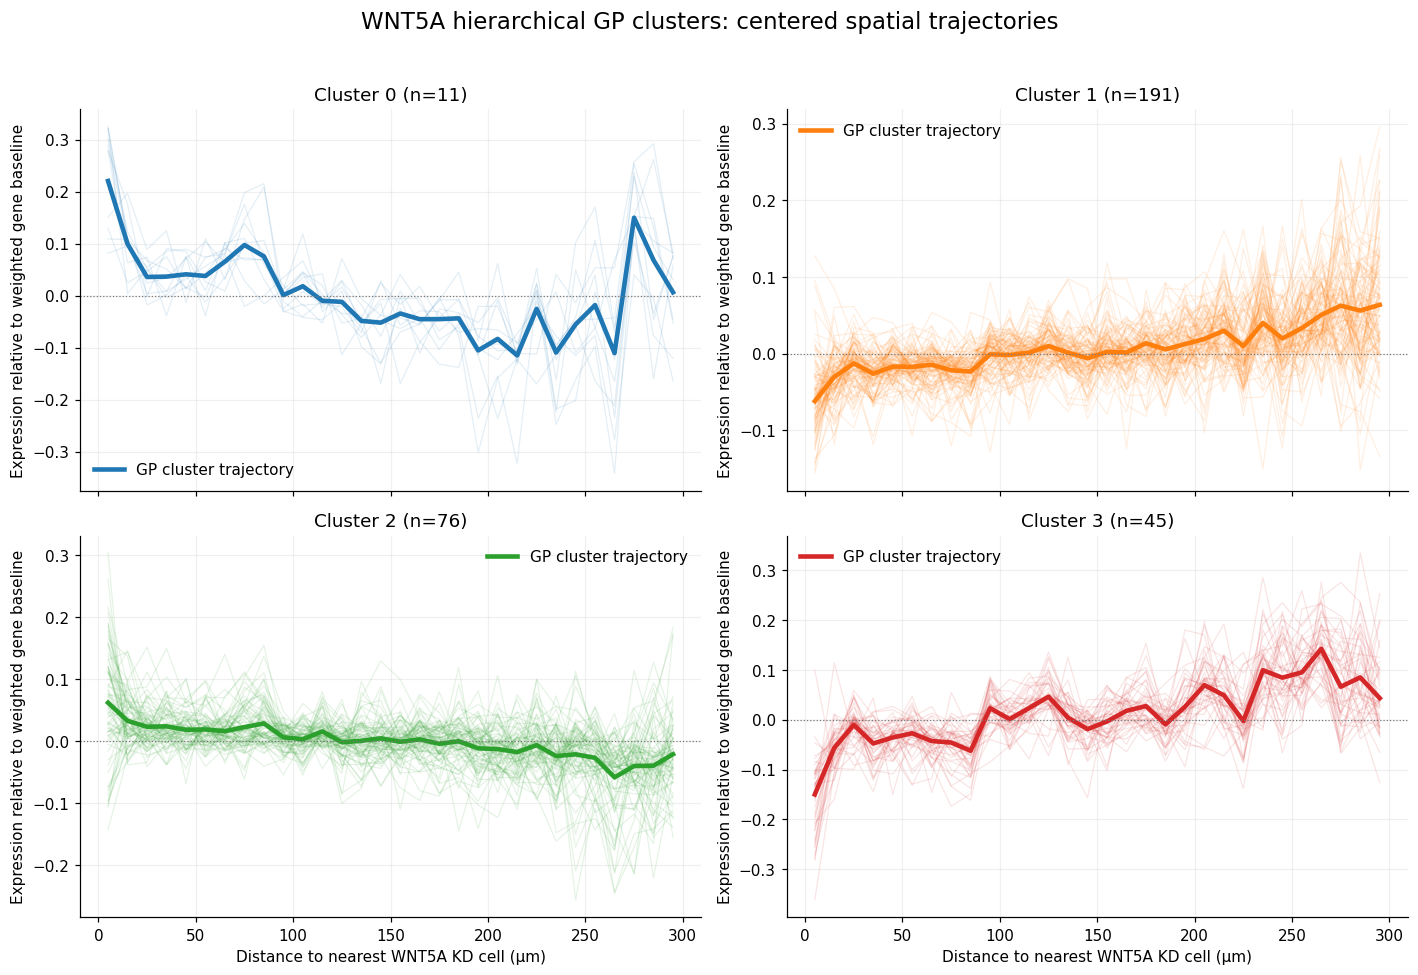

In [11]:
colors = mpl.colormaps["tab10"](np.arange(CLUSTERS))
random = np.random.default_rng(20260723)
figure, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for cluster, axis in enumerate(axes.ravel()):
    members = np.flatnonzero(cluster_id == cluster)
    shown = (
        random.choice(members, size=100, replace=False)
        if members.size > 100
        else members
    )
    axis.plot(
        X[:, 0],
        Y_model[shown].T,
        color=colors[cluster],
        alpha=0.12,
        linewidth=0.8,
    )
    axis.plot(
        X[:, 0],
        cluster_means_model[:, cluster],
        color=colors[cluster],
        linewidth=3,
        label="GP cluster trajectory",
    )
    axis.axhline(0.0, color="#777777", linewidth=0.8, linestyle=":")
    axis.set_title(f"Cluster {cluster} (n={members.size})")
    axis.set_ylabel("Expression relative to weighted gene baseline")
    axis.grid(alpha=0.18)
    axis.legend(frameon=False)

for axis in axes[-1]:
    axis.set_xlabel("Distance to nearest WNT5A KD cell (µm)")
figure.suptitle(
    "WNT5A hierarchical GP clusters: centered spatial trajectories",
    fontsize=15,
)
figure.tight_layout(rect=[0, 0, 1, 0.96])
figure.savefig(
    OUTPUT_DIR / "wnt5a_gpclust_centered_trajectories.png",
    bbox_inches="tight",
)
figure.savefig(
    OUTPUT_DIR / "wnt5a_gpclust_centered_trajectories.pdf",
    bbox_inches="tight",
)
plt.show()



## 7. Original-scale cluster profiles

Baseline levels are shown separately because each gene had a different
center removed. These panels use the hard assignments from the best restart
and summarize the uncentered profiles empirically. The band is the
across-gene interquartile range; the solid and dashed lines are the arithmetic
mean and median.



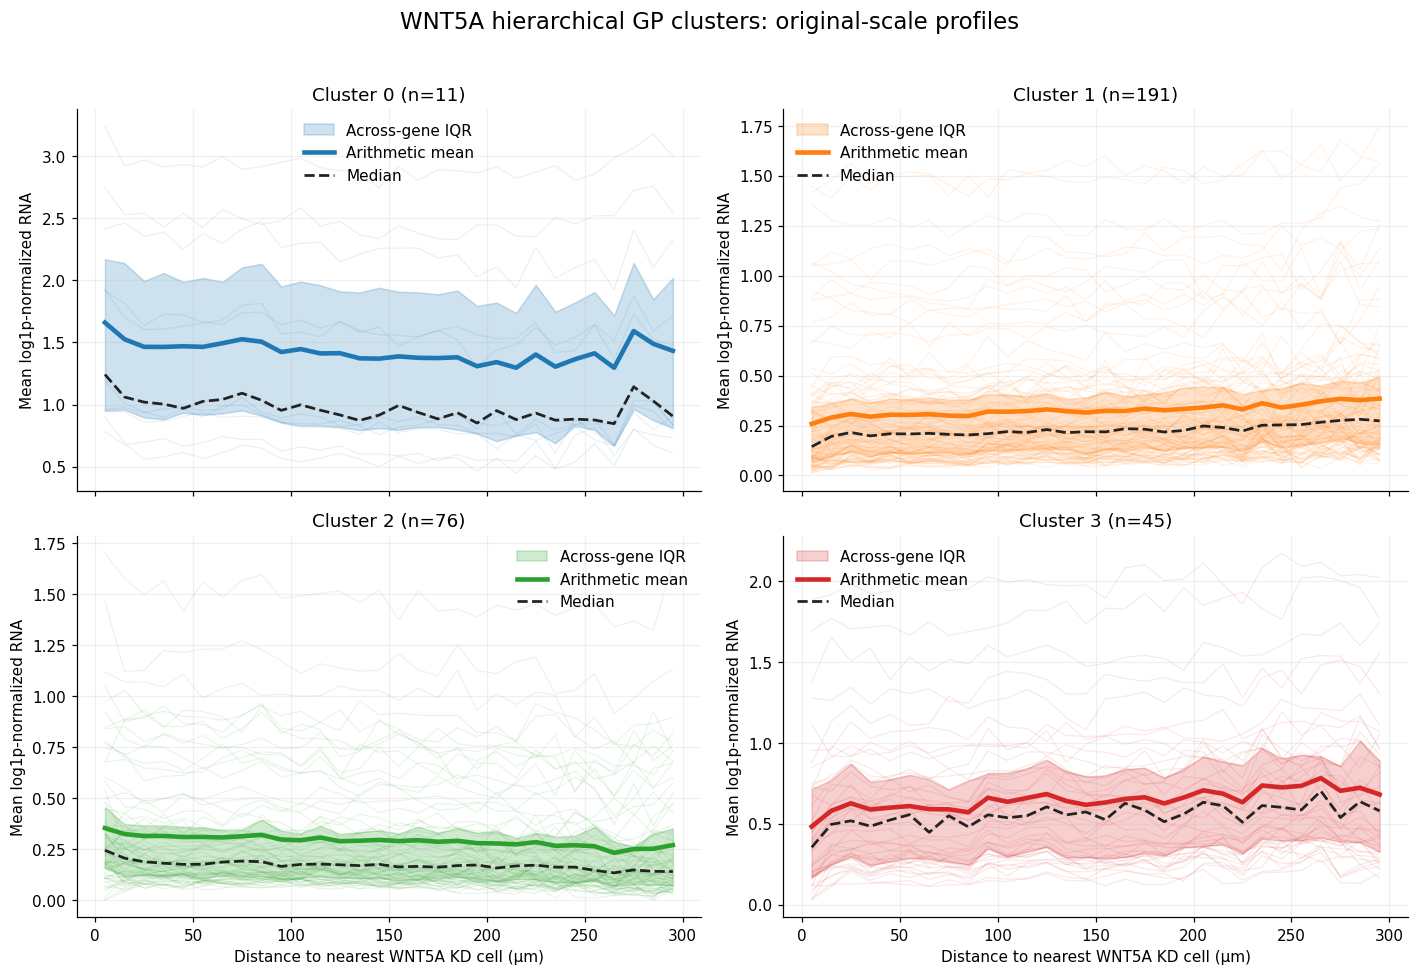

In [12]:
original_summary_rows = []
figure, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
random = np.random.default_rng(20260723)

for cluster, axis in enumerate(axes.ravel()):
    members = np.flatnonzero(cluster_id == cluster)
    profiles = selected_Y_mean[members]
    shown = (
        random.choice(members, size=100, replace=False)
        if members.size > 100
        else members
    )
    mean_profile = profiles.mean(axis=0)
    median_profile = np.median(profiles, axis=0)
    q25 = np.quantile(profiles, 0.25, axis=0)
    q75 = np.quantile(profiles, 0.75, axis=0)
    original_summary_rows.append(
        {
            "cluster": cluster,
            "genes": members.size,
            "mean_assignment_probability": float(
                assignment_probability[members].mean()
            ),
            "mean_at_5_um": mean_profile[0],
            "mean_at_295_um": mean_profile[-1],
        }
    )

    axis.plot(
        X[:, 0],
        selected_Y_mean[shown].T,
        color=colors[cluster],
        alpha=0.10,
        linewidth=0.8,
    )
    axis.fill_between(
        X[:, 0],
        q25,
        q75,
        color=colors[cluster],
        alpha=0.22,
        label="Across-gene IQR",
    )
    axis.plot(
        X[:, 0],
        mean_profile,
        color=colors[cluster],
        linewidth=3,
        label="Arithmetic mean",
    )
    axis.plot(
        X[:, 0],
        median_profile,
        color="#222222",
        linewidth=1.8,
        linestyle="--",
        label="Median",
    )
    axis.set_title(f"Cluster {cluster} (n={members.size})")
    axis.set_ylabel("Mean log1p-normalized RNA")
    axis.grid(alpha=0.18)
    axis.legend(frameon=False)

for axis in axes[-1]:
    axis.set_xlabel("Distance to nearest WNT5A KD cell (µm)")
figure.suptitle(
    "WNT5A hierarchical GP clusters: original-scale profiles",
    fontsize=15,
)
figure.tight_layout(rect=[0, 0, 1, 0.96])
figure.savefig(
    OUTPUT_DIR / "wnt5a_gpclust_original_scale_profiles.png",
    bbox_inches="tight",
)
figure.savefig(
    OUTPUT_DIR / "wnt5a_gpclust_original_scale_profiles.pdf",
    bbox_inches="tight",
)
plt.show()

cluster_summary = pd.DataFrame(original_summary_rows)
cluster_summary["responsibility_sum"] = responsibilities.sum(axis=0)
display(cluster_summary)



## 8. Reproducibility summary

The exact cluster labels can permute, and small numerical differences across
BLAS implementations can alter the landscape of non-winning restarts. In the
separately archived reference run, seed 5 was best and seed 7 recovered the
same partition up to label permutation with a bound lower by only 0.0088. In a
clean validation run of this notebook, seed 5 reproduced the primary partition
exactly while seeds 6 and 7 reached different lower-bound alternatives. Several
other restarts collapse one or more hard clusters. The primary result is always
selected by the largest finite variational lower bound.



In [13]:
reproducibility_summary = pd.DataFrame(
    {
        "check": [
            "Input dimensions",
            "BH-significant genes",
            "Top-ten order",
            "Weighted-centering residual",
            "No variance normalization",
            "Best restart seed",
            "Best variational bound",
            "Hard cluster sizes",
            "Median assignment probability",
            "Fixed White variance",
        ],
        "observed": [
            f"{Y_mean.shape[0]:,} genes × {Y_mean.shape[1]} bins",
            selected_positions.size,
            ", ".join(top10["gene"]),
            f"{np.max(np.abs(weighted_residual)):.3e}",
            True,
            best_fit["seed"],
            f"{best_fit['bound']:.6f}",
            str(cluster_counts.tolist()),
            f"{np.median(assignment_probability):.6f}",
            f"{best_fit['white_noise_variance']:.12g}",
        ],
        "reference": [
            "10,789 genes × 30 bins",
            323,
            ", ".join(expected_top10),
            "< 1e-12",
            True,
            "5 in the pinned reference run",
            "16094.150103",
            "[11, 191, 76, 45] up to label permutation",
            "0.999894",
            "0.0015228009318",
        ],
    }
)
display(reproducibility_summary)

package_versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "SciPy": importlib.import_module("scipy").__version__,
        "pandas": pd.__version__,
        "Matplotlib": mpl.__version__,
        "GPy": GPy.__version__,
        "GPClust commit": GPCLUST_COMMIT,
        "GPClust source SHA-256": gpclust_source_sha256,
    },
    name="version",
)
display(package_versions.to_frame())



All reference comparisons passed in the pinned validation environment.


## Appendix: export compact binned inputs for all ligand and NTC targets

This optional section preserves the repository's original all-target export
workflow. It is not required for the WNT5A result above and is skipped by
default because it loads the full multiome object and writes a large ZIP file.



In [14]:
RUN_ALL_TARGET_EXPORT = False


def export_all_target_inputs():
    import re
    import zipfile

    raw = load_raw_multiome()
    target_calls = raw["target_calls"]
    eb_clusters = raw["eb_clusters"]
    spatial = raw["spatial"]
    rna_X = raw["rna_X"]
    all_gene_names = raw["gene_names"]

    with h5py.File(CATATAC_PATH, "r") as handle:
        guide_strings = read_categorical(handle["obs"]["guides_passing_str"])

    all_targets = [
        "WNT5A",
        "WNT1",
        "BMP5",
        "BMP7",
        "JAG1",
        "DLL3",
        "VEGFB",
        "PDGFC",
        "EFNA3",
        "RSPO3",
        "SEMA6D",
        "NECTIN2",
        "NECTIN3",
        "ALB",
        "B2M",
    ]
    ntc_guides = [
        "Negative control-1",
        "Negative control-2",
        "Negative control-3",
        "Negative control-5",
    ]
    ntc_pattern = re.compile(
        r"^(Negative control-\d+)(;Negative control-\d+)*$"
    )
    pure_ntc_mask = np.array(
        [bool(value and ntc_pattern.match(value)) for value in guide_strings]
    )
    excluded = {"Unassigned", "No_CRISPR_data", "Non-Targeting"}
    bins = [(10 * i, 10 * (i + 1)) for i in range(30)]
    bin_midpoints = (5.0 + 10.0 * np.arange(30))[:, None]
    export_dir = OUTPUT_DIR / "binned_data"
    export_dir.mkdir(parents=True, exist_ok=True)

    def compute_and_export(name, reference_mask, query_mask):
        distances = np.full(target_calls.size, np.inf)
        for eb in np.unique(eb_clusters):
            in_eb = eb_clusters == eb
            reference = reference_mask & in_eb
            query = query_mask & in_eb
            if reference.sum() < 1 or query.sum() < 1:
                continue
            distance, _ = KDTree(spatial[reference]).query(spatial[query])
            distances[np.flatnonzero(query)] = distance
        valid = query_mask & (distances <= 300)
        cells_by_bin = []
        for index, (lower, upper) in enumerate(bins):
            upper_test = (
                distances <= upper if index == 29 else distances < upper
            )
            cells_by_bin.append(
                np.flatnonzero(
                    valid & (distances >= lower) & upper_test
                )
            )
        bin_counts = np.array([cells.size for cells in cells_by_bin])
        if bin_counts.sum() == 0:
            print(f"{name}: no binned cells; skipped")
            return

        all_cells = np.concatenate(cells_by_bin)
        detection = np.asarray(
            (rna_X[all_cells] != 0).mean(axis=0)
        ).ravel()
        selected = np.flatnonzero(detection > 0.05)
        means = np.zeros((30, selected.size))
        sems = np.zeros_like(means)
        for index, cells in enumerate(cells_by_bin):
            if cells.size == 0:
                continue
            values = rna_X[cells][:, selected].toarray()
            means[index] = values.mean(axis=0)
            sems[index] = values.std(axis=0) / np.sqrt(cells.size)
        np.savez_compressed(
            export_dir / f"{name}.npz",
            X=bin_midpoints,
            means=means,
            sems=sems,
            mean_sem_sq=np.mean(np.square(sems), axis=0),
            detection=detection[selected],
            gene_names=all_gene_names[selected],
            gene_indices=selected,
            bin_counts=bin_counts,
            n_reference_cells=int(reference_mask.sum()),
            n_binned_cells=int(all_cells.size),
        )
        print(
            f"{name}: {reference_mask.sum():,} reference cells, "
            f"{all_cells.size:,} binned cells, {selected.size:,} genes"
        )

    for target in all_targets:
        reference = target_calls == target
        query = np.array(
            [
                value not in excluded and value != target
                for value in target_calls
            ]
        )
        compute_and_export(target, reference, query)

    for ntc_guide in ntc_guides:
        reference = np.array(
            [
                bool(
                    value
                    and ntc_pattern.match(value)
                    and ntc_guide in value
                )
                for value in guide_strings
            ]
        )
        query = (
            np.array([value not in excluded for value in target_calls])
            & ~pure_ntc_mask
        )
        compute_and_export(
            ntc_guide.replace("Negative control-", "NTC_"),
            reference,
            query,
        )

    zip_path = OUTPUT_DIR / "binned_data.zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as handle:
        for path in sorted(export_dir.glob("*.npz")):
            handle.write(path, f"binned_data/{path.name}")
    print(f"Saved {zip_path}")


if RUN_ALL_TARGET_EXPORT:
    export_all_target_inputs()
else:
    print("Optional all-target export skipped.")
